## Business Case:- 
* In the semiconductor industry, one of the most critical and time-consuming challenges during the chip design phase is ensuring that a design meets its timing requirements — that is, whether it can operate at the required speed without delay or failure. Traditionally, this verification relies on simulation and Electronic Design Automation (EDA) tools, which are computationally expensive and can take several hours to days to complete. To address this inefficiency, I have developed an AI-powered machine learning model that predicts whether a chip design will meet timing or not, using early-stage design parameters such as design complexity, lines of code, target frequency, EDA runtime, and bugs found during simulation. This solution enables design engineers to detect potential failures early, optimize their designs proactively, and avoid unnecessary simulation costs. As a result, the model significantly shortens the design validation cycle, reduces development costs, and enhances the decision-making process. By integrating AI into the design phase of semiconductor supply chain management, this approach adds measurable business value and gives companies a competitive edge by accelerating the overall time-to-market.

#### Domain Name:- AI & Chip Design Focused

## Domain Analysis

* Domain Analysis is the process of deeply studying and understanding a specific area (domain) of knowledge or business — like semiconductor design, supply chain, or AI in healthcare — so that you can build efficient, reusable, and relevant AI/tech solutions in that space.

In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [247]:
data = pd.read_csv("semiconductor_design_phase_large.csv")
data

,Design_ID,Design_Complexity,Lines_of_Code,Num_Modules,Target_Power_mW,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Meets_Timing,Estimated_Power_Usage_mW
0,DGN_10000,Medium,51940,19,172.13,481.06,Cadence,810.46,0,1,160.132941
1,DGN_10001,Low,82947,46,225.37,594.80,OpenROAD,1106.09,2,0,239.562393
2,DGN_10002,High,90001,28,296.60,2480.70,Synopsys,1139.12,3,1,298.592711
3,DGN_10003,High,24642,30,160.38,1907.41,OpenROAD,251.29,2,0,157.712262
4,DGN_10004,Medium,72643,30,179.55,2408.73,Synopsys,358.47,2,0,204.893914
...,...,...,...,...,...,...,...,...,...,...,...
4995,DGN_14995,High,26230,7,176.83,2232.22,Cadence,348.34,3,1,155.070297
4996,DGN_14996,Medium,23680,23,82.39,1475.78,Cadence,496.96,1,1,80.559498
4997,DGN_14997,Medium,87694,24,267.90,1555.31,Mentor,538.97,1,0,288.573005
4998,DGN_14998,Medium,89731,29,139.47,505.56,Synopsys,407.39,3,0,139.107111


**Attribute Information:-**

**Design_Complexity**
→ How difficult or advanced the chip design is (Low, Medium, High).
More complex designs may be harder to get right.

**Lines_of_Code**
→ Total number of code lines used to describe the chip design.
More code usually means more functions and possibly more issues.

**Num_Modules**
→ Number of separate functional parts (modules) in the design.
Too many modules can make coordination and timing harder.

**Target_Power_mW**
→ How much power (in milliwatts) the chip is expected to consume.
Lower power is better, but too low might affect performance.

**Target_Frequency_MHz**
→ The desired operating speed of the chip in MHz.
Higher frequency = faster chip, but also harder to meet timing.

**Design_Tool_Used**
→ Which software (like Synopsys, Cadence) was used to create the design.
Different tools might impact design quality and performance.

**EDA_Runtime_min**
→ How long (in minutes) the design tool took to simulate the chip.
Long runtimes may mean more complex or less optimized designs.

**Simulation_Bugs_Found**
→ Number of issues/errors found during simulation/testing.
More bugs = higher chance the chip won’t meet its goals.

**Estimated_Power_Usage_mW**
→ Estimated actual power the chip might use, based on prediction.
Deviation from target power might impact reliability or efficiency.

**Meets_Timing**
→ Will the chip design meet timing requirements?

## Basic Check

* A basic check refers to initial validations or reviews you do before starting modeling — to ensure your data, features, and environment are clean, correct, and ready for further steps.

In [248]:
data.head()

,Design_ID,Design_Complexity,Lines_of_Code,Num_Modules,Target_Power_mW,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Meets_Timing,Estimated_Power_Usage_mW
0,DGN_10000,Medium,51940,19,172.13,481.06,Cadence,810.46,0,1,160.132941
1,DGN_10001,Low,82947,46,225.37,594.80,OpenROAD,1106.09,2,0,239.562393
2,DGN_10002,High,90001,28,296.60,2480.70,Synopsys,1139.12,3,1,298.592711
3,DGN_10003,High,24642,30,160.38,1907.41,OpenROAD,251.29,2,0,157.712262
4,DGN_10004,Medium,72643,30,179.55,2408.73,Synopsys,358.47,2,0,204.893914


In [249]:
data.tail()

,Design_ID,Design_Complexity,Lines_of_Code,Num_Modules,Target_Power_mW,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Meets_Timing,Estimated_Power_Usage_mW
4995,DGN_14995,High,26230,7,176.83,2232.22,Cadence,348.34,3,1,155.070297
4996,DGN_14996,Medium,23680,23,82.39,1475.78,Cadence,496.96,1,1,80.559498
4997,DGN_14997,Medium,87694,24,267.90,1555.31,Mentor,538.97,1,0,288.573005
4998,DGN_14998,Medium,89731,29,139.47,505.56,Synopsys,407.39,3,0,139.107111
4999,DGN_14999,Medium,47340,15,206.51,2158.66,Synopsys,166.66,3,1,204.266222


In [250]:
data.describe()

,Lines_of_Code,Num_Modules,Target_Power_mW,Target_Frequency_MHz,EDA_Runtime_min,Simulation_Bugs_Found,Meets_Timing,Estimated_Power_Usage_mW
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,52281.176400,26.686400,176.833594,1325.791072,622.417628,1.984600,0.695200,177.310573
std,27731.010451,12.976569,71.983736,693.612793,327.890817,1.433309,0.460369,73.814207
min,5005.000000,5.000000,50.060000,100.120000,60.080000,0.000000,0.000000,30.000000
25%,27527.000000,16.000000,114.847500,733.980000,336.777500,1.000000,0.000000,116.148897
50%,52751.500000,26.000000,177.920000,1334.960000,623.525000,2.000000,1.000000,177.425619
75%,76540.750000,38.000000,238.907500,1922.282500,905.477500,3.000000,1.000000,239.561093
max,99990.000000,49.000000,299.980000,2499.760000,1199.690000,10.000000,1.000000,332.381199


In [251]:
data.describe(include="O")

,Design_ID,Design_Complexity,Design_Tool_Used
count,5000,5000,5000
unique,5000,3,4
top,DGN_10000,Medium,Mentor
freq,1,2510,1297


In [252]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Design_ID                 5000 non-null   object 
 1   Design_Complexity         5000 non-null   object 
 2   Lines_of_Code             5000 non-null   int64  
 3   Num_Modules               5000 non-null   int64  
 4   Target_Power_mW           5000 non-null   float64
 5   Target_Frequency_MHz      5000 non-null   float64
 6   Design_Tool_Used          5000 non-null   object 
 7   EDA_Runtime_min           5000 non-null   float64
 8   Simulation_Bugs_Found     5000 non-null   int64  
 9   Meets_Timing              5000 non-null   int64  
 10  Estimated_Power_Usage_mW  5000 non-null   float64
dtypes: float64(4), int64(4), object(3)
memory usage: 429.8+ KB


## EDA:- Exploratory Data Analysis

* EDA stands for Exploratory Data Analysis.

* EDA stands for Exploratory Data Analysis. It is an approach in data analysis where you use various techniques (such as visualization, statistical tests, and summary statistics) to understand the underlying patterns, trends, relationships, and anomalies in your data before applying more advanced modeling techniques.

### 1. Univariant Analysis

* Univariate analysis refers to the analysis of a single variable (or feature) in a dataset. The goal is to summarize and find patterns in the data for that particular variable without considering relationships with other variables. It helps in understanding the distribution and characteristics of the variable, including its central tendency, spread, and shape.

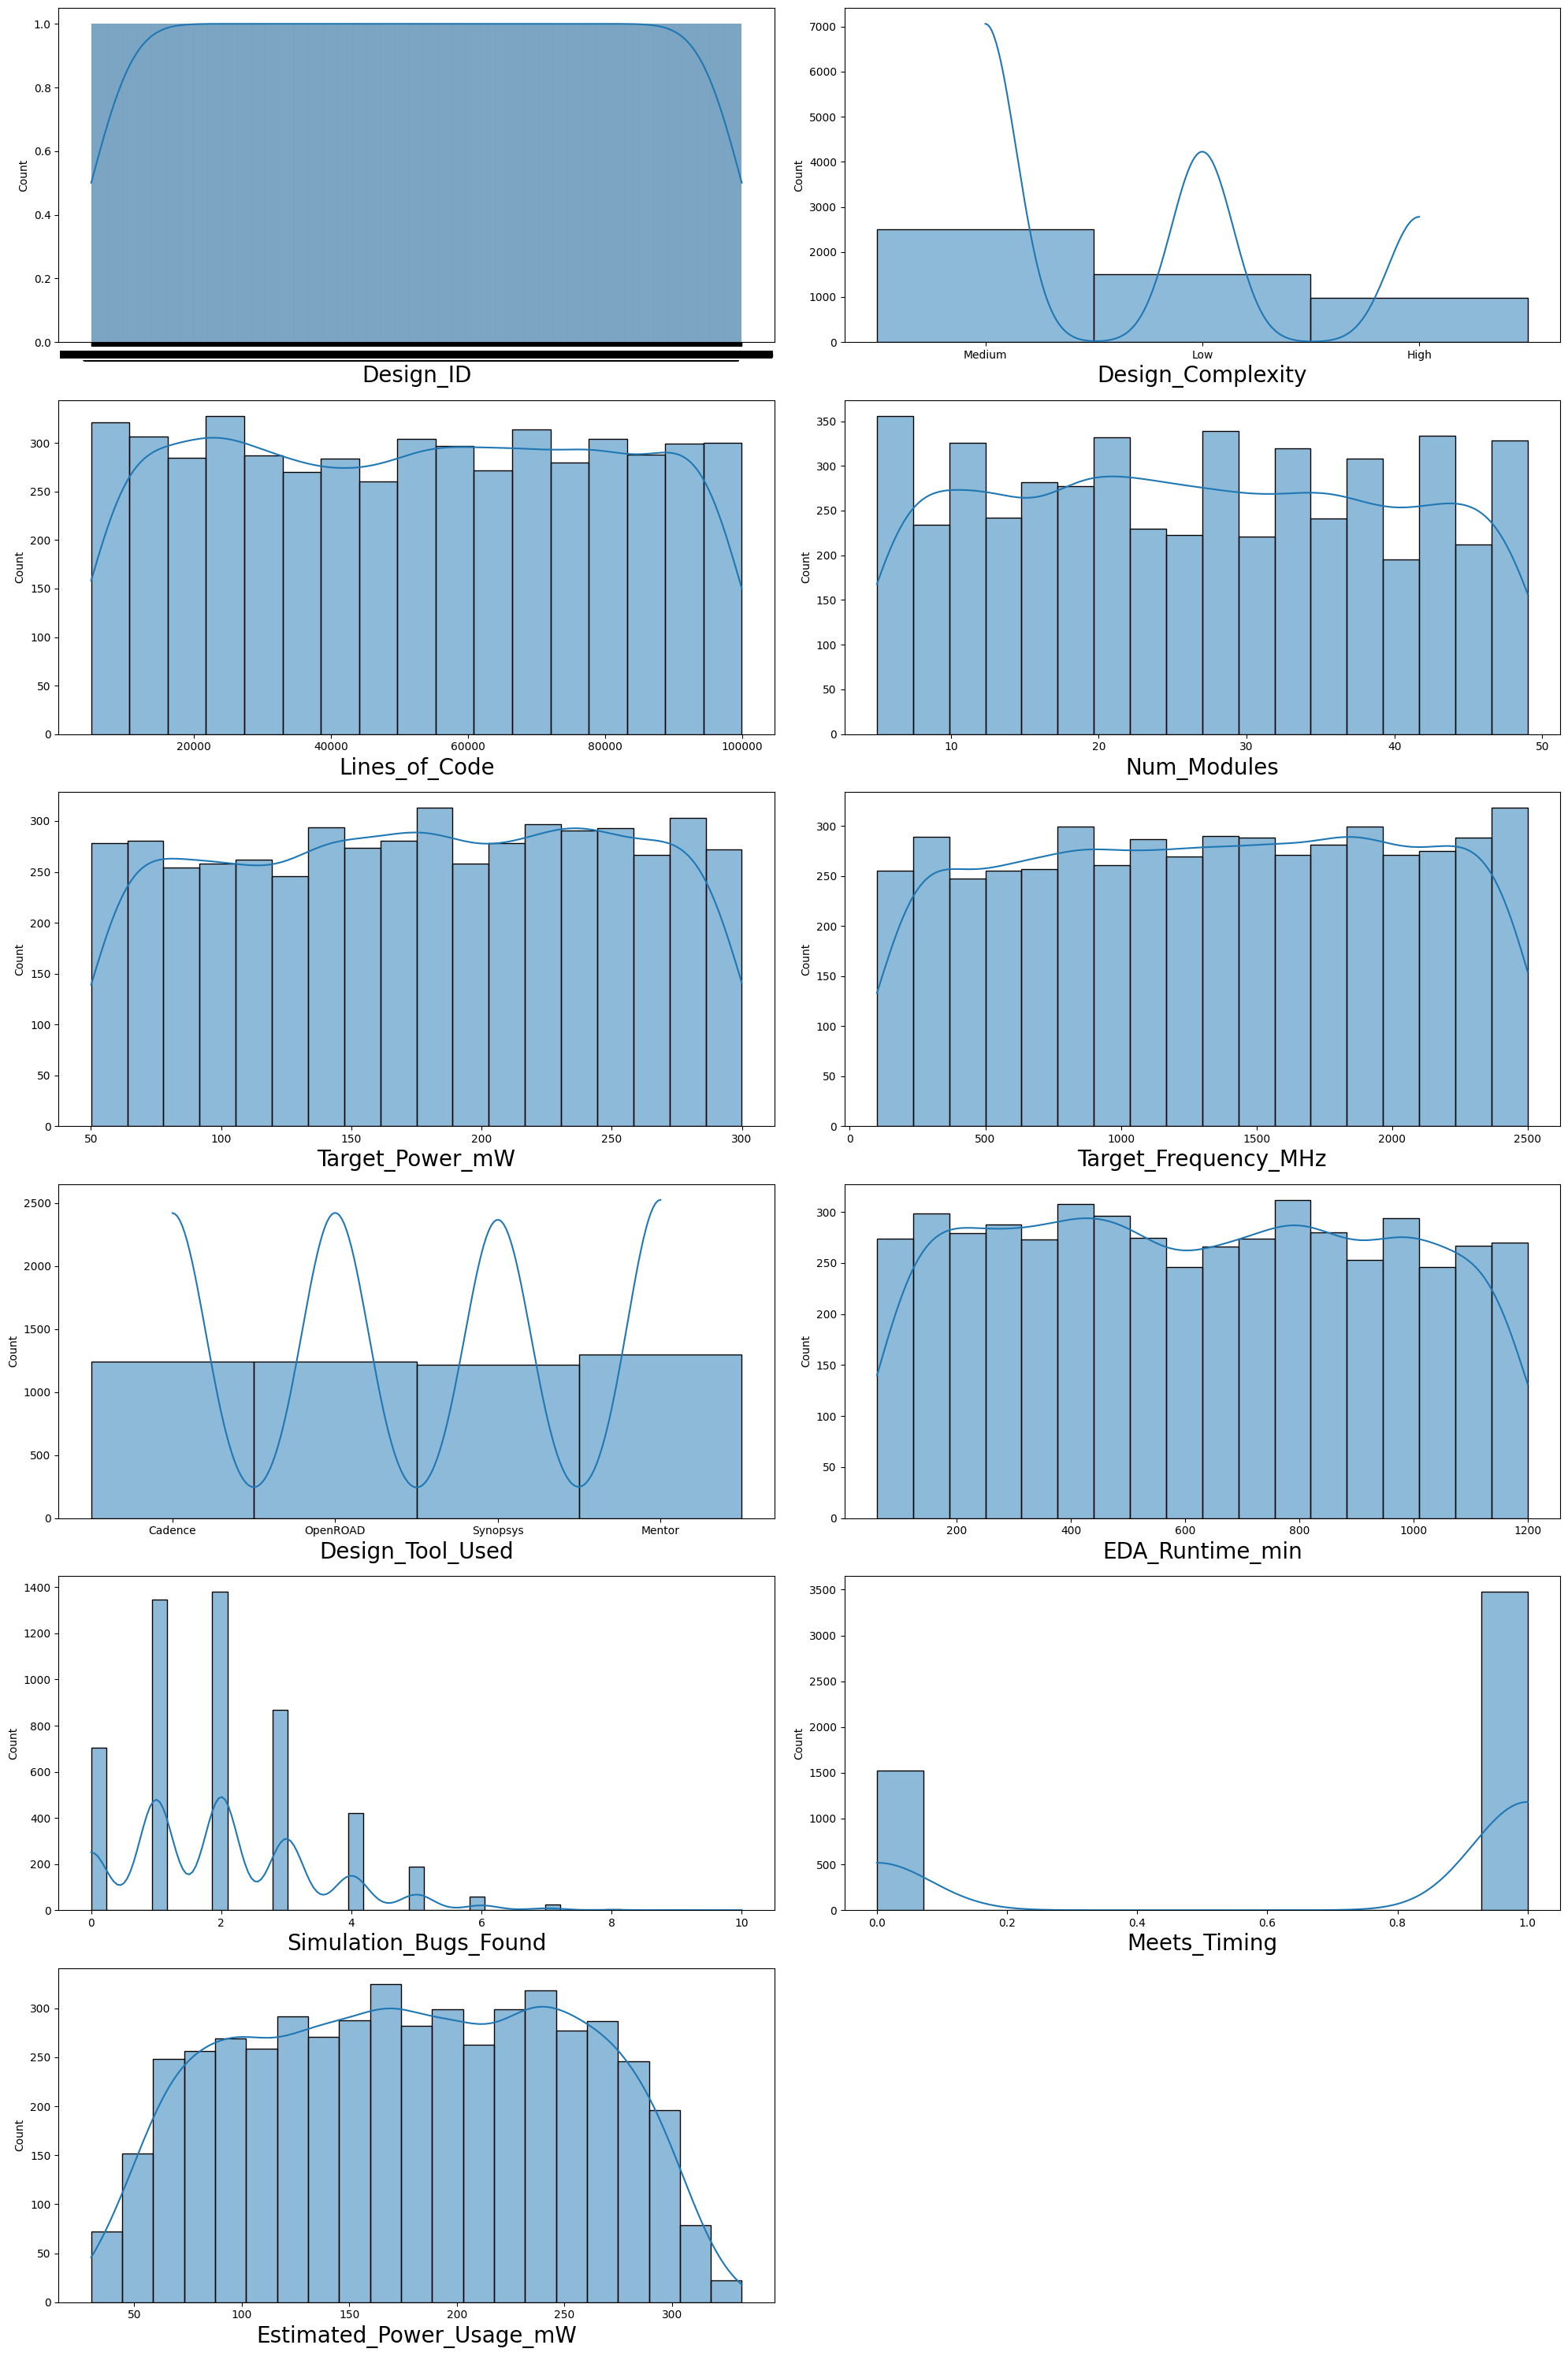

In [12]:
plt.figure(figsize=(20,30))
plt_num = 1
for column in data:
    if plt_num <= 11:
        plt.subplot(6,2,plt_num)
        sns.histplot(data[column],kde=True)
        plt.xlabel(column,fontsize=20)
    plt_num += 1
plt.tight_layout()

### Biavariant Analysis

* Bivariate analysis refers to the analysis of the relationship between two variables. Unlike univariate analysis, which focuses on one variable at a time, bivariate analysis aims to examine how two variables are related, whether they are dependent or independent, and what kind of relationship (if any) exists between them.

* Bivariate analysis can be used with both categorical and numerical data, and it helps in understanding the nature of the association between the two variables

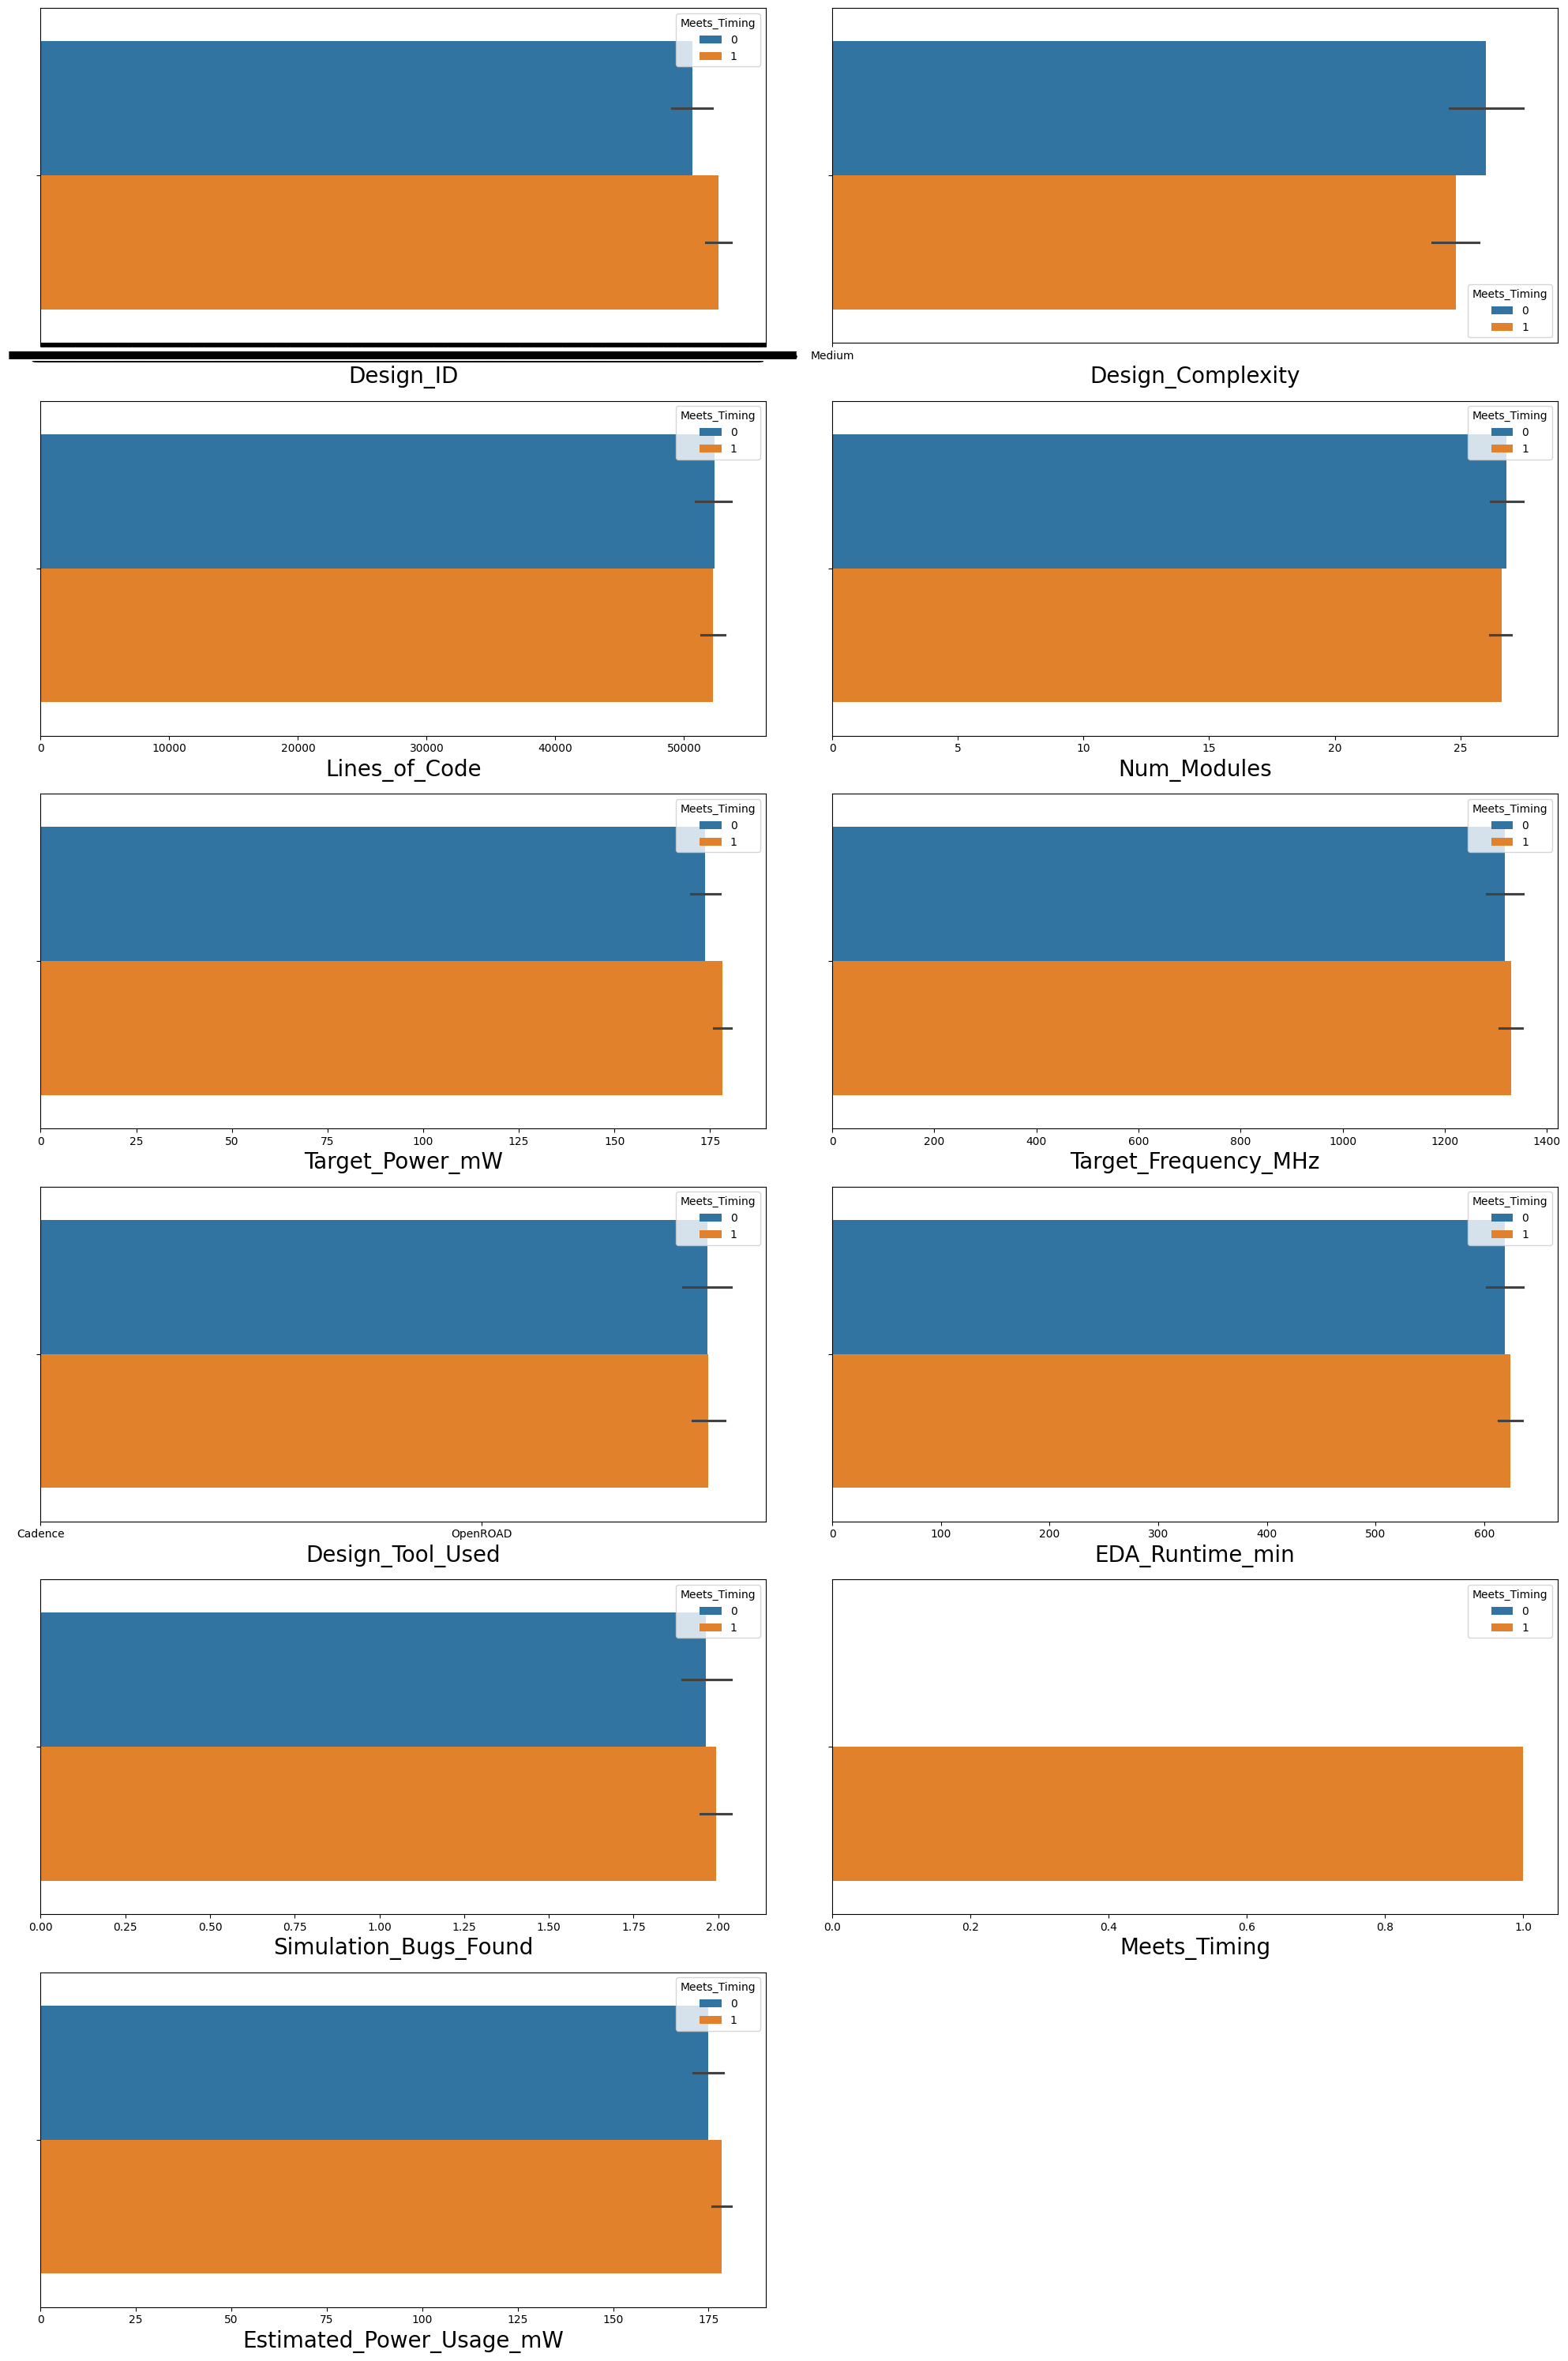

In [14]:
plt.figure(figsize=(20,30))
plt_num = 1
for column in data:
    if plt_num <= 11:
        plt.subplot(6,2,plt_num)
        sns.barplot(x = data[column],hue = data["Meets_Timing"])
        plt.xlabel(column,fontsize=20)
    plt_num += 1
plt.tight_layout()

### Mutlivariant Analysis

* Multivariate analysis refers to the analysis of more than two variables simultaneously. It extends the concept of univariate and bivariate analysis by considering multiple variables at once and examining the relationships and interactions between them. The goal is to understand complex patterns and relationships within a dataset and to model more realistic situations where multiple factors influence an outcome.

In [ ]:
sns.pairplot(data)

## Feature Engineering

* Feature Engineering is the process of transforming raw data into meaningful features that better represent the underlying patterns and structures of the data for machine learning algorithms. This step is crucial in building accurate models because the quality and relevance of features directly impact model performance. Feature engineering involves selecting, modifying, or creating new features based on domain knowledge and the patterns within the data.

### 1. Data Preprocessing

* Data Preprocessing is a crucial step in the data science and machine learning pipeline that involves preparing raw data for analysis and modeling. The goal of data preprocessing is to clean, transform, and format the data into a suitable structure that enhances the performance of machine learning algorithms. It ensures that the data is of high quality and ready for further analysis or model building.

In [253]:
data.isnull().sum()

Design_ID                   0
Design_Complexity           0
Lines_of_Code               0
Num_Modules                 0
Target_Power_mW             0
Target_Frequency_MHz        0
Design_Tool_Used            0
EDA_Runtime_min             0
Simulation_Bugs_Found       0
Meets_Timing                0
Estimated_Power_Usage_mW    0
dtype: int64

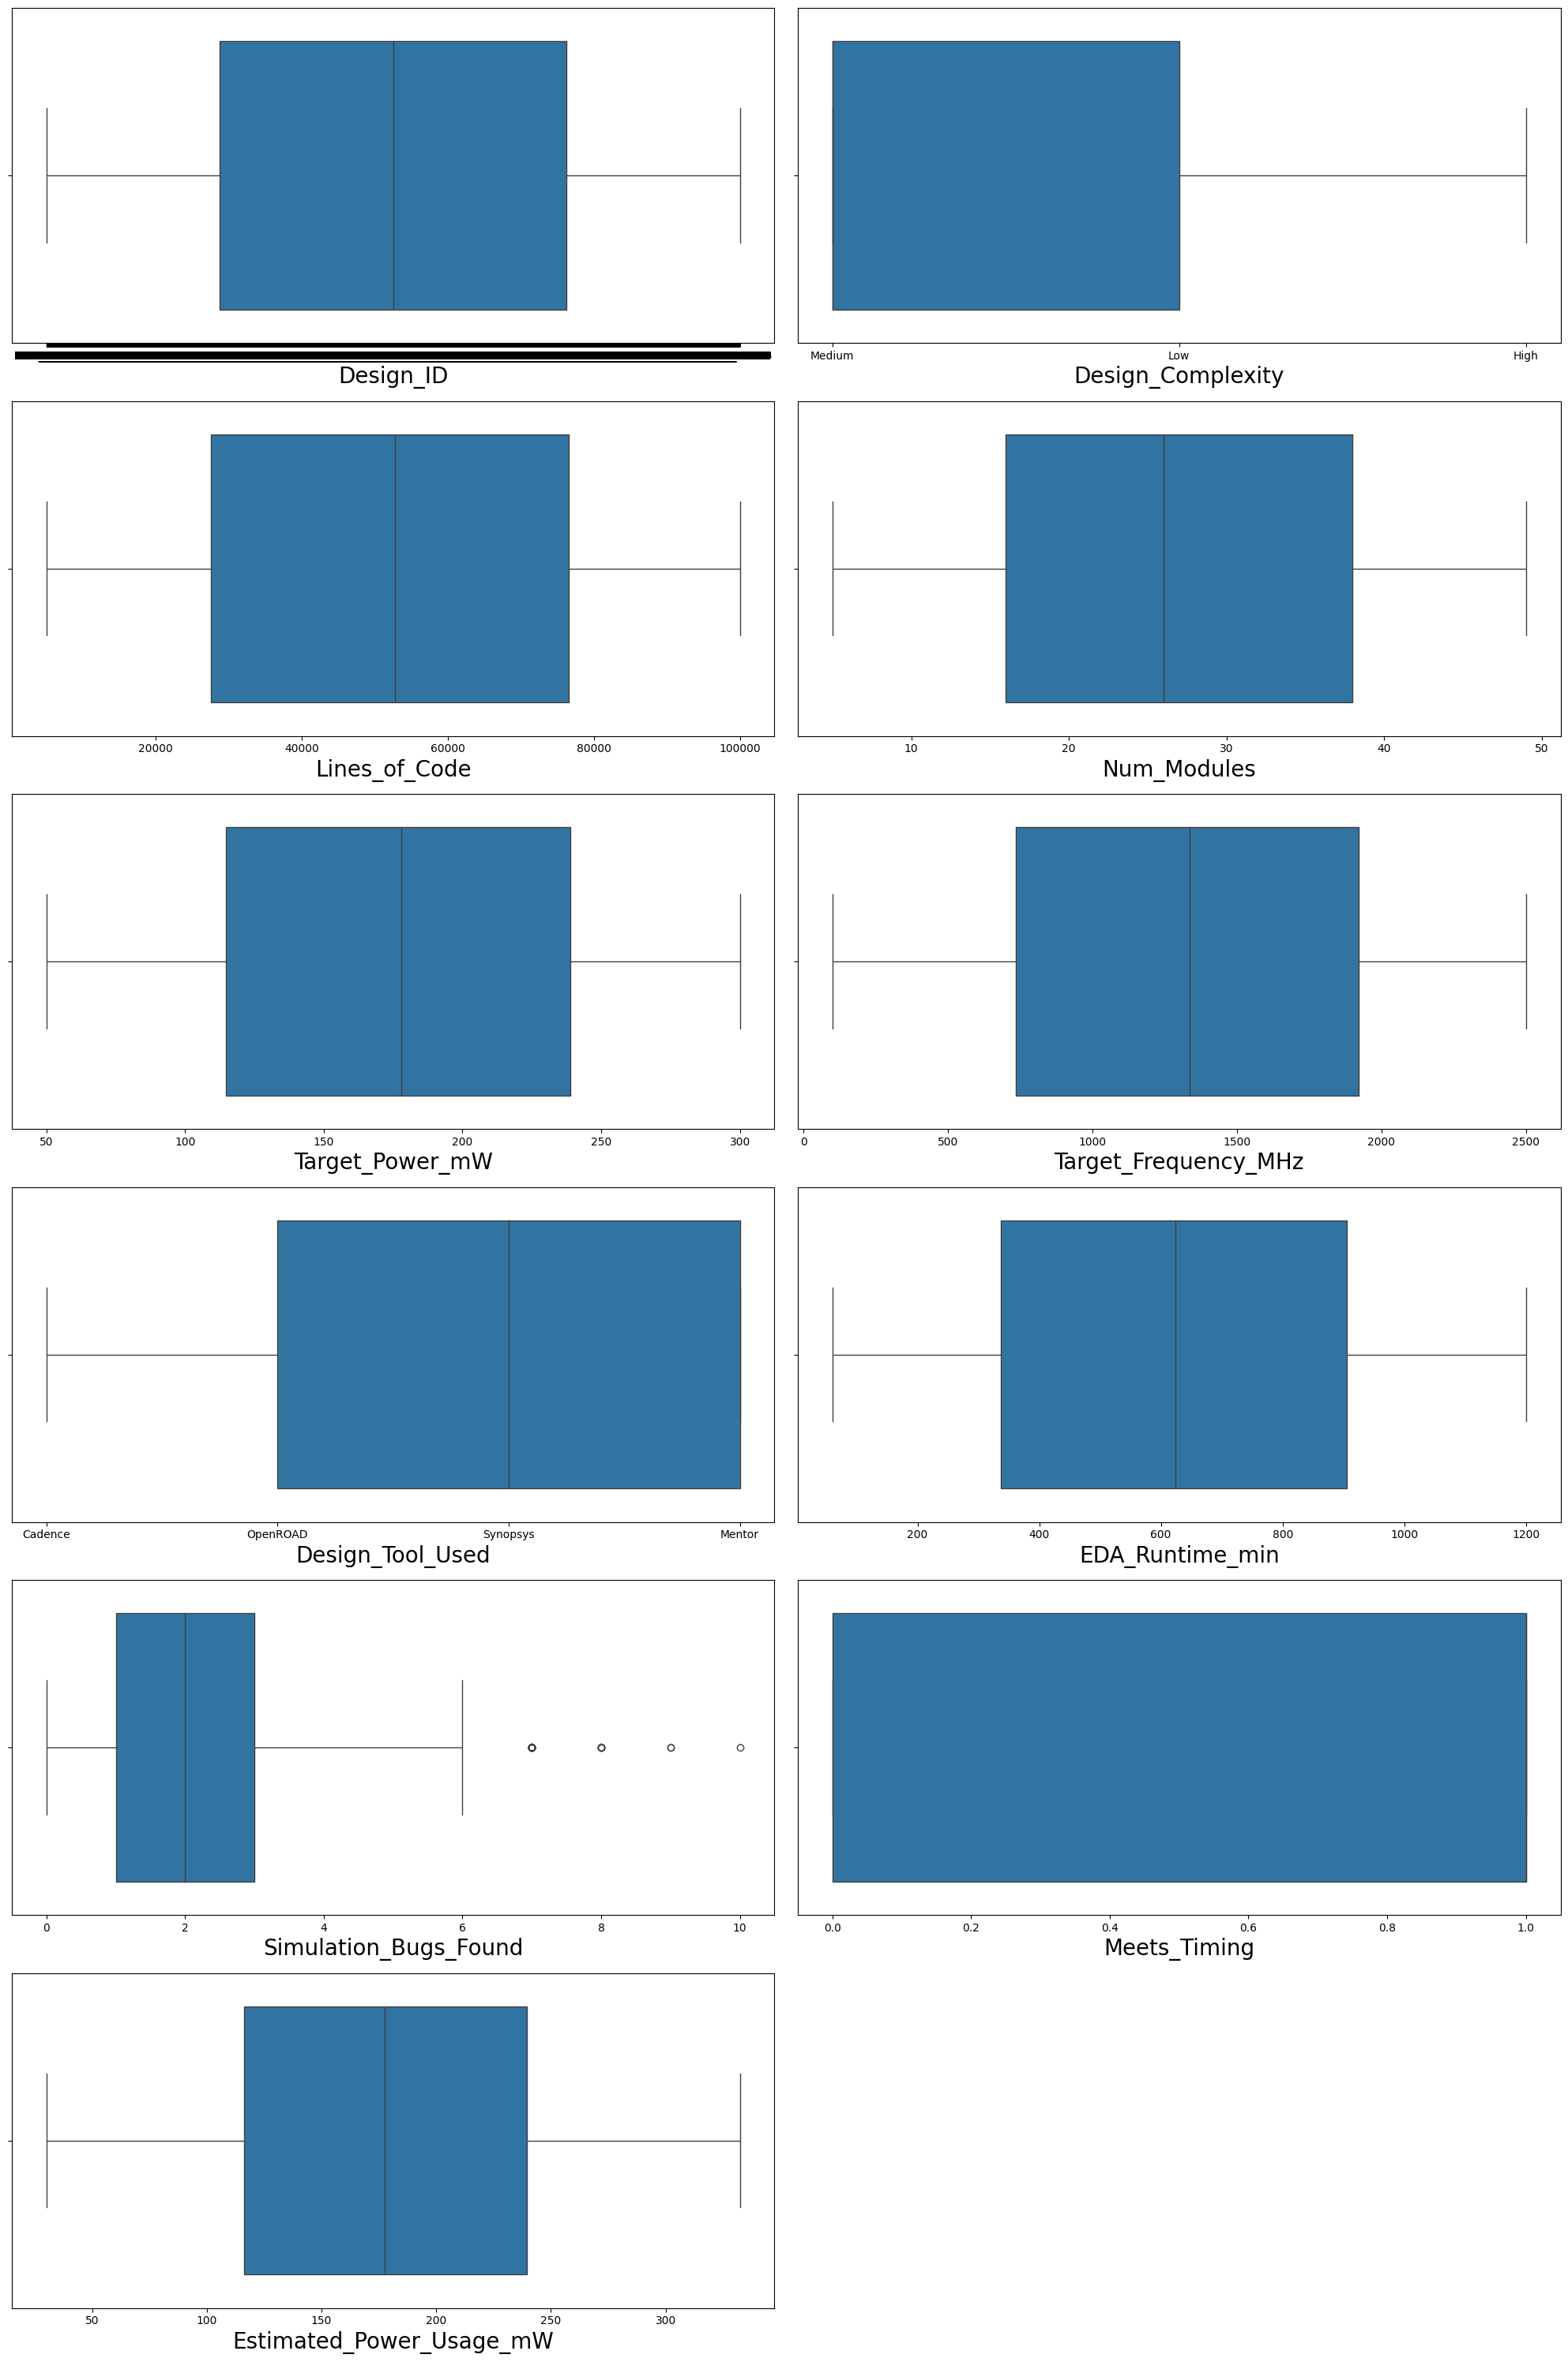

In [46]:
plt.figure(figsize=(20,30))
plt_num = 1
for column in data:
    if plt_num <= 11:
        plt.subplot(6,2,plt_num)
        sns.boxplot(x = data[column])
        plt.xlabel(column,fontsize=20)
    plt_num += 1
plt.tight_layout()

In [254]:
data.head()

,Design_ID,Design_Complexity,Lines_of_Code,Num_Modules,Target_Power_mW,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Meets_Timing,Estimated_Power_Usage_mW
0,DGN_10000,Medium,51940,19,172.13,481.06,Cadence,810.46,0,1,160.132941
1,DGN_10001,Low,82947,46,225.37,594.80,OpenROAD,1106.09,2,0,239.562393
2,DGN_10002,High,90001,28,296.60,2480.70,Synopsys,1139.12,3,1,298.592711
3,DGN_10003,High,24642,30,160.38,1907.41,OpenROAD,251.29,2,0,157.712262
4,DGN_10004,Medium,72643,30,179.55,2408.73,Synopsys,358.47,2,0,204.893914


In [255]:
data.drop(["Design_ID"],axis=1,inplace=True)

In [256]:
data.head()

,Design_Complexity,Lines_of_Code,Num_Modules,Target_Power_mW,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Meets_Timing,Estimated_Power_Usage_mW
0,Medium,51940,19,172.13,481.06,Cadence,810.46,0,1,160.132941
1,Low,82947,46,225.37,594.80,OpenROAD,1106.09,2,0,239.562393
2,High,90001,28,296.60,2480.70,Synopsys,1139.12,3,1,298.592711
3,High,24642,30,160.38,1907.41,OpenROAD,251.29,2,0,157.712262
4,Medium,72643,30,179.55,2408.73,Synopsys,358.47,2,0,204.893914


In [257]:
data["Design_Tool_Used"].unique()

array(['Cadence', 'OpenROAD', 'Synopsys', 'Mentor'], dtype=object)

In [258]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["Design_Tool_Used"] = le.fit_transform(data["Design_Tool_Used"])
data["Design_Complexity"] = le.fit_transform(data["Design_Complexity"])

In [259]:
data.head()

,Design_Complexity,Lines_of_Code,Num_Modules,Target_Power_mW,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Meets_Timing,Estimated_Power_Usage_mW
0,2,51940,19,172.13,481.06,0,810.46,0,1,160.132941
1,1,82947,46,225.37,594.80,2,1106.09,2,0,239.562393
2,0,90001,28,296.60,2480.70,3,1139.12,3,1,298.592711
3,0,24642,30,160.38,1907.41,2,251.29,2,0,157.712262
4,2,72643,30,179.55,2408.73,3,358.47,2,0,204.893914


In [260]:
# from sklearn.preprocessing import OneHotEncoder
# oe = OneHotEncoder()
# df = pd.get_dummies(data["Design_Complexity"],dtype=int,prefix="Design")
# df1 = pd.get_dummies(data["Design_Tool_Used"],dtype=int,prefix="Design_Tool")

In [261]:
# df

In [262]:
# data = pd.concat([data,df,df1],axis=1)
# data

In [263]:
# data.drop(["Design_Complexity","Design_Tool_Used"],axis=1,inplace=True)

In [264]:
data.head()

,Design_Complexity,Lines_of_Code,Num_Modules,Target_Power_mW,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Meets_Timing,Estimated_Power_Usage_mW
0,2,51940,19,172.13,481.06,0,810.46,0,1,160.132941
1,1,82947,46,225.37,594.80,2,1106.09,2,0,239.562393
2,0,90001,28,296.60,2480.70,3,1139.12,3,1,298.592711
3,0,24642,30,160.38,1907.41,2,251.29,2,0,157.712262
4,2,72643,30,179.55,2408.73,3,358.47,2,0,204.893914


In [266]:
data.drop(["Target_Power_mW"],axis=1,inplace=True)

### 2. Feature Selection

* Feature Selection is the process of selecting a subset of the most relevant features (or variables) from a larger set of features in a dataset. The goal is to improve the performance of machine learning models by reducing the number of input variables, thus simplifying the model, increasing its accuracy, reducing overfitting, and improving computational efficiency

<Axes: >

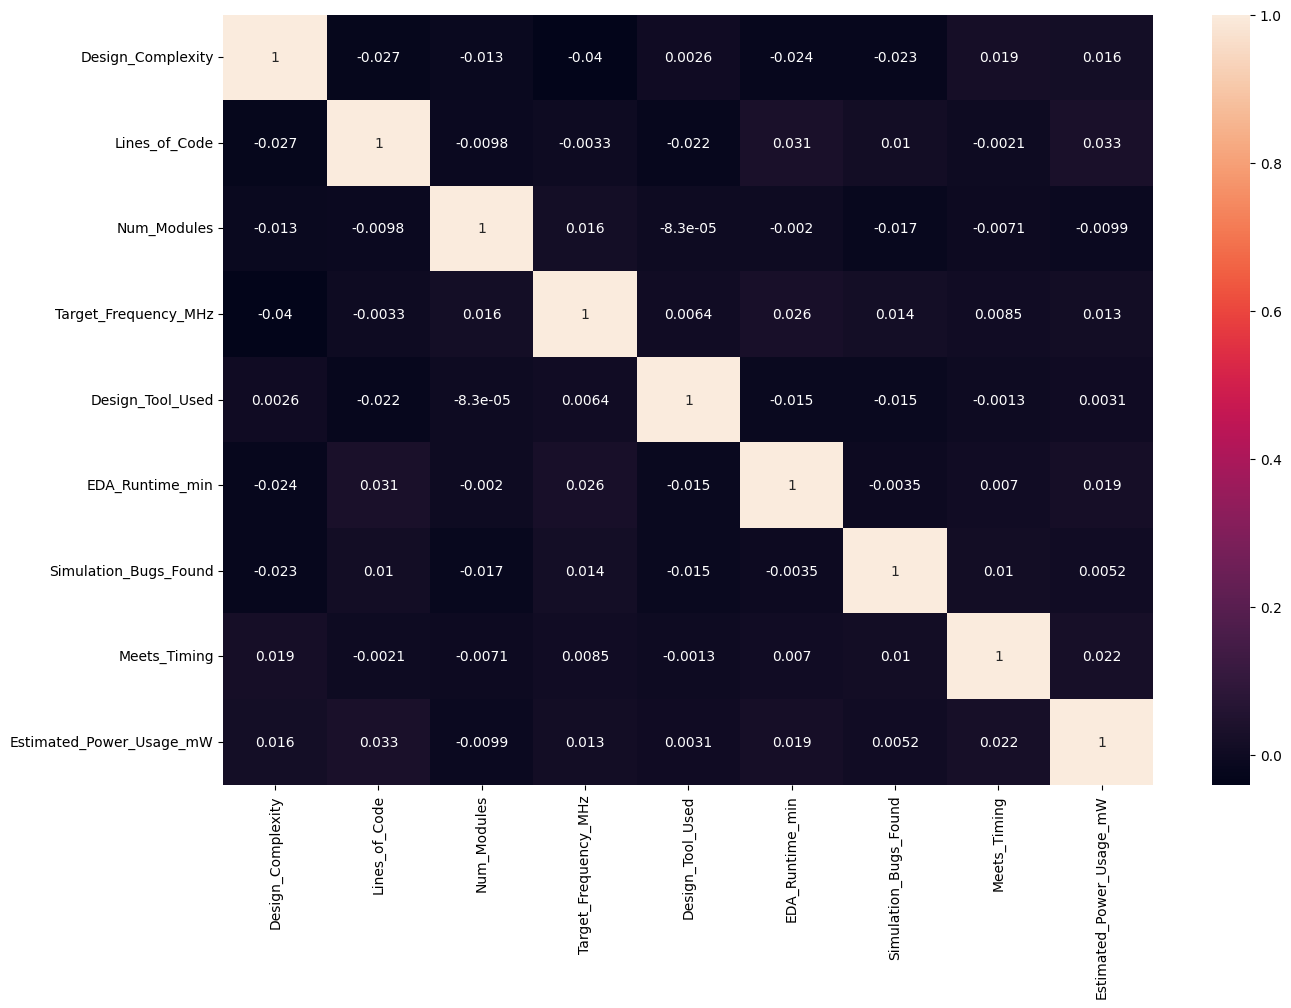

In [267]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(),annot=True)

## Model Creation

In [268]:
x = data.drop(["Meets_Timing"],axis=1)
y = data["Meets_Timing"]

In [269]:
x

,Design_Complexity,Lines_of_Code,Num_Modules,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Estimated_Power_Usage_mW
0,2,51940,19,481.06,0,810.46,0,160.132941
1,1,82947,46,594.80,2,1106.09,2,239.562393
2,0,90001,28,2480.70,3,1139.12,3,298.592711
3,0,24642,30,1907.41,2,251.29,2,157.712262
4,2,72643,30,2408.73,3,358.47,2,204.893914
...,...,...,...,...,...,...,...,...
4995,0,26230,7,2232.22,0,348.34,3,155.070297
4996,2,23680,23,1475.78,0,496.96,1,80.559498
4997,2,87694,24,1555.31,1,538.97,1,288.573005
4998,2,89731,29,505.56,3,407.39,3,139.107111


In [270]:
y

0       1
1       0
2       1
3       0
4       0
       ..
4995    1
4996    1
4997    0
4998    0
4999    1
Name: Meets_Timing, Length: 5000, dtype: int64

In [271]:
data["Meets_Timing"].value_counts()

Meets_Timing
1    3476
0    1524
Name: count, dtype: int64

In [272]:
from sklearn.preprocessing import MinMaxScaler
me =  MinMaxScaler()
df1 = me.fit_transform(x)
df1

array([[1.        , 0.49413065, 0.31818182, ..., 0.65845333, 0.        ,
        0.43036056],
       [0.5       , 0.82057167, 0.93181818, ..., 0.91786664, 0.2       ,
        0.69304042],
       [0.        , 0.89483603, 0.52272727, ..., 0.94685024, 0.3       ,
        0.88825864],
       ...,
       [1.        , 0.87054798, 0.43181818, ..., 0.42022271, 0.1       ,
        0.85512263],
       [1.        , 0.89199347, 0.54545455, ..., 0.30476216, 0.3       ,
        0.36082637],
       [1.        , 0.44570195, 0.22727273, ..., 0.09352322, 0.3       ,
        0.57631302]])

In [273]:
x.columns

Index(['Design_Complexity', 'Lines_of_Code', 'Num_Modules',
       'Target_Frequency_MHz', 'Design_Tool_Used', 'EDA_Runtime_min',
       'Simulation_Bugs_Found', 'Estimated_Power_Usage_mW'],
      dtype='object')

In [275]:
X = pd.DataFrame(df1,columns=['Design_Complexity', 'Lines_of_Code', 'Num_Modules',
       'Target_Frequency_MHz', 'Design_Tool_Used', 'EDA_Runtime_min',
       'Simulation_Bugs_Found', 'Estimated_Power_Usage_mW'])
X

,Design_Complexity,Lines_of_Code,Num_Modules,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Estimated_Power_Usage_mW
0,1.0,0.494131,0.318182,0.158749,0.000000,0.658453,0.0,0.430361
1,0.5,0.820572,0.931818,0.206148,0.666667,0.917867,0.2,0.693040
2,0.0,0.894836,0.522727,0.992057,1.000000,0.946850,0.3,0.888259
3,0.0,0.206738,0.568182,0.753150,0.666667,0.167785,0.2,0.422355
4,1.0,0.712091,0.568182,0.962065,1.000000,0.261835,0.2,0.578389
...,...,...,...,...,...,...,...,...
4995,0.0,0.223456,0.045455,0.888508,0.000000,0.252946,0.3,0.413618
4996,1.0,0.196610,0.409091,0.573278,0.000000,0.383359,0.1,0.167205
4997,1.0,0.870548,0.431818,0.606420,0.333333,0.420223,0.1,0.855123
4998,1.0,0.891993,0.545455,0.168959,1.000000,0.304762,0.3,0.360826


In [276]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [277]:
x_train

,Design_Complexity,Lines_of_Code,Num_Modules,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Estimated_Power_Usage_mW
2913,0,45724,21,1100.66,2,941.06,2,228.053650
3275,1,67963,5,1118.65,2,367.02,0,99.312024
775,0,5684,22,2262.49,1,205.88,2,225.581663
217,1,14677,39,1164.15,1,898.59,1,251.178798
1245,2,21661,30,2451.20,3,597.09,1,261.908014
...,...,...,...,...,...,...,...,...
4931,0,91058,35,1504.60,1,1063.23,3,196.617307
3264,1,46435,27,188.41,3,902.35,2,98.392774
1653,0,81464,43,266.67,2,313.52,2,225.246778
2607,1,86556,47,1355.79,0,343.97,1,174.291172


In [278]:
x_test

,Design_Complexity,Lines_of_Code,Num_Modules,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Estimated_Power_Usage_mW
398,2,64052,25,793.19,1,1096.46,3,171.698572
3833,0,24455,45,1505.34,1,675.14,3,252.162460
4836,2,40200,18,2374.38,2,665.04,1,316.296890
4572,2,92659,35,1130.78,3,1044.23,2,262.783850
636,2,12399,18,2010.49,1,915.49,1,272.771686
...,...,...,...,...,...,...,...,...
4228,2,68172,11,1075.01,0,151.03,2,153.971468
2367,2,62500,27,1613.24,0,1085.00,3,59.532444
788,1,95555,29,379.71,3,183.37,4,195.696548
1452,1,94595,41,1062.57,1,222.31,1,238.420462


In [279]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
x_train_smoe,y_train_smote = sm.fit_resample(x_train,y_train)

In [280]:
from collections import Counter
print("Before",Counter(y_test))
print("After",Counter(y_train_smote))

Before Counter({1: 670, 0: 330})
After Counter({0: 2806, 1: 2806})


## Model Selection

### Logistic Regression Algorithm

In [281]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [282]:
y_lr = lr.predict(x_test)

In [283]:
from sklearn.metrics import *

In [284]:
accuracy_score(y_test,y_lr)

0.67

In [285]:
y_tlr = lr.predict(x_train)

In [286]:
accuracy_score(y_train,y_tlr)

0.7015

In [287]:
print(classification_report(y_test,y_lr))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       330
           1       0.67      1.00      0.80       670

    accuracy                           0.67      1000
   macro avg       0.34      0.50      0.40      1000
weighted avg       0.45      0.67      0.54      1000



## Decision Tree Algorithm

In [357]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=5,criterion="entropy",min_samples_leaf=4)
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=4)

In [358]:
y_dt = dt.predict(x_test)

In [359]:
accuracy_score(y_test,y_dt)

0.671

In [360]:
y_tdt = dt.predict(x_train)

In [361]:
accuracy_score(y_train,y_tdt)

0.705

In [362]:
print(classification_report(y_test,y_dt))

              precision    recall  f1-score   support

           0       0.55      0.02      0.04       330
           1       0.67      0.99      0.80       670

    accuracy                           0.67      1000
   macro avg       0.61      0.51      0.42      1000
weighted avg       0.63      0.67      0.55      1000



## RandomForest Algorithm

In [389]:
from sklearn.ensemble import RandomForestClassifier
rm = RandomForestClassifier(n_estimators=200,max_depth=3,max_features="log2",min_samples_split=17)
rm.fit(x_train,y_train)

RandomForestClassifier(max_depth=3, max_features='log2', min_samples_split=17,
                       n_estimators=200)

In [390]:
y_rm = rm.predict(x_test)

In [391]:
accuracy_score(y_test,y_rm)

0.671

In [392]:
y_trm = rm.predict(x_train)

In [393]:
accuracy_score(y_train,y_trm)

0.70275

In [368]:
print(classification_report(y_test,y_rm))

              precision    recall  f1-score   support

           0       1.00      0.00      0.01       330
           1       0.67      1.00      0.80       670

    accuracy                           0.67      1000
   macro avg       0.84      0.50      0.40      1000
weighted avg       0.78      0.67      0.54      1000



## Gradiant Boosting Algorithm

In [424]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=200,max_depth=2,learning_rate=0.01)
gb.fit(x_train,y_train)

GradientBoostingClassifier(learning_rate=0.01, max_depth=2, n_estimators=200)

In [425]:
y_gb = gb.predict(x_test)

In [426]:
accuracy_score(y_test,y_gb)

0.671

In [427]:
y_tgb = gb.predict(x_train)

In [428]:
accuracy_score(y_train,y_tgb)

0.70275

In [429]:
print(classification_report(y_test,y_gb))

              precision    recall  f1-score   support

           0       1.00      0.00      0.01       330
           1       0.67      1.00      0.80       670

    accuracy                           0.67      1000
   macro avg       0.84      0.50      0.40      1000
weighted avg       0.78      0.67      0.54      1000



## XGBoost Algorithm

In [460]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=300,max_depth=3,learning_rate = 0.01)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [461]:
y_xgb = xgb.predict(x_test)

In [462]:
accuracy_score(y_test,y_xgb)

0.67

In [463]:
y_txgb = xgb.predict(x_train)

In [464]:
accuracy_score(y_train,y_txgb)

0.7015

In [465]:
print(classification_report(y_test,y_xgb))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       330
           1       0.67      1.00      0.80       670

    accuracy                           0.67      1000
   macro avg       0.34      0.50      0.40      1000
weighted avg       0.45      0.67      0.54      1000



## Model Save

In [479]:
import pickle
with open("Semi.pkl","wb") as f:
    pickle.dump(gb,f)

In [480]:
with open("Semi.pkl","rb") as f:
    file = pickle.load(f)

In [481]:
file

GradientBoostingClassifier(learning_rate=0.01, max_depth=2, n_estimators=200)

In [482]:
x_train

,Design_Complexity,Lines_of_Code,Num_Modules,Target_Frequency_MHz,Design_Tool_Used,EDA_Runtime_min,Simulation_Bugs_Found,Estimated_Power_Usage_mW
2913,0,45724,21,1100.66,2,941.06,2,228.053650
3275,1,67963,5,1118.65,2,367.02,0,99.312024
775,0,5684,22,2262.49,1,205.88,2,225.581663
217,1,14677,39,1164.15,1,898.59,1,251.178798
1245,2,21661,30,2451.20,3,597.09,1,261.908014
...,...,...,...,...,...,...,...,...
4931,0,91058,35,1504.60,1,1063.23,3,196.617307
3264,1,46435,27,188.41,3,902.35,2,98.392774
1653,0,81464,43,266.67,2,313.52,2,225.246778
2607,1,86556,47,1355.79,0,343.97,1,174.291172


In [483]:
y_train

2913    0
3275    1
775     1
217     1
1245    1
       ..
4931    1
3264    0
1653    1
2607    1
2732    1
Name: Meets_Timing, Length: 4000, dtype: int64

In [484]:
file.predict([[0	,5684	,22	,2262.49,	1	,205.88,	2	,225.581663]])

array([1], dtype=int64)